In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import os
import glob
import warnings
warnings.filterwarnings("ignore")

os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = os.environ["PATH"] + r";C:\hadoop\bin"

#Create the spark session
spark = SparkSession.builder \
    .appName("MyApp") \
    .config("spark.driver.memory", "10g") \
    .getOrCreate()


#Path to the folder with all the  files
files = glob.glob(os.path.join(r"C:\Users\mekay\Downloads\MIT805_DATA", "*.parquet"))

#Import failed a few times due to varying datatypes for the same column: passenger_count
#Decided to just convert all of them to doubles

dfs = [] #list for all our dataframes that we will eventually union
for f in files:
    d = spark.read.parquet(f)
    d = d.withColumn("passenger_count", col("passenger_count").cast("double"))
    dfs.append(d)

#Start with our first dataframe
df = dfs[0]

#Go through the list and append them
for d in dfs[1:]:
    df = df.unionByName(d, allowMissingColumns=True)


#Our Zone look up table
zones = spark.read.csv(r"C:\Users\mekay\Downloads\MIT805_DATA\taxi_zone_lookup.csv", header=True, inferSchema=True)
zones.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows



### Creating the Funnel

In [2]:
#Base table
df.createOrReplaceTempView("taxi_data")
zones.createOrReplaceTempView("zones")

In [3]:
pair_counts = spark.sql("""
    SELECT p.zone_a,
           p.zone_b,
           za.Zone AS zone_a_name,
           zb.Zone AS zone_b_name,
           p.avg_speed,
           p.avg_distance,
           p.trips
    FROM (
        SELECT CASE WHEN PULocationID < DOLocationID THEN PULocationID ELSE DOLocationID END AS zone_a,
               CASE WHEN PULocationID < DOLocationID THEN DOLocationID ELSE PULocationID END AS zone_b,
               ROUND(AVG(average_trip_speed), 2) AS avg_speed,
               ROUND(AVG(trip_distance), 2) AS avg_distance,
               COUNT(*) AS trips -- Counts the number of trips
        FROM taxi_data
        WHERE PULocationID <> DOLocationID
          AND YEAR(tpep_pickup_datetime) = 2025
          AND HOUR(tpep_pickup_datetime) BETWEEN 8 AND 17
        GROUP BY 1, 2 -- Grouping by the PU and DO locations mentioned in the 1st and 2nd lines of this inner select statement
        HAVING AVG(trip_distance) > 1 - Filters for those routes that on average are greater than 1 mile
    ) p
    JOIN zones za ON p.zone_a = za.LocationID
    JOIN zones zb ON p.zone_b = zb.LocationID
    ORDER BY p.trips DESC
""")

pair_counts.toPandas().to_excel(r"C:\Users\mekay\Downloads\pair_counts.xlsx", index=False)
pair_counts.show(5)

+------+------+--------------------+--------------------+---------+------------+-----+
|zone_a|zone_b|         zone_a_name|         zone_b_name|avg_speed|avg_distance|trips|
+------+------+--------------------+--------------------+---------+------------+-----+
| 236.0| 237.0|Upper East Side N...|Upper East Side S...|     8.16|        1.01|72467|
| 161.0| 237.0|      Midtown Center|Upper East Side S...|     6.33|        1.02|35002|
| 161.0| 236.0|      Midtown Center|Upper East Side N...|     7.66|        1.85|24718|
| 141.0| 236.0|     Lenox Hill West|Upper East Side N...|     7.93|        1.07|22907|
| 142.0| 237.0| Lincoln Square East|Upper East Side S...|      7.7|        1.28|18247|
+------+------+--------------------+--------------------+---------+------------+-----+
only showing top 5 rows



In [ ]:
import matplotlib.pyplot as plt

pdf = pair_counts.limit(100).toPandas()

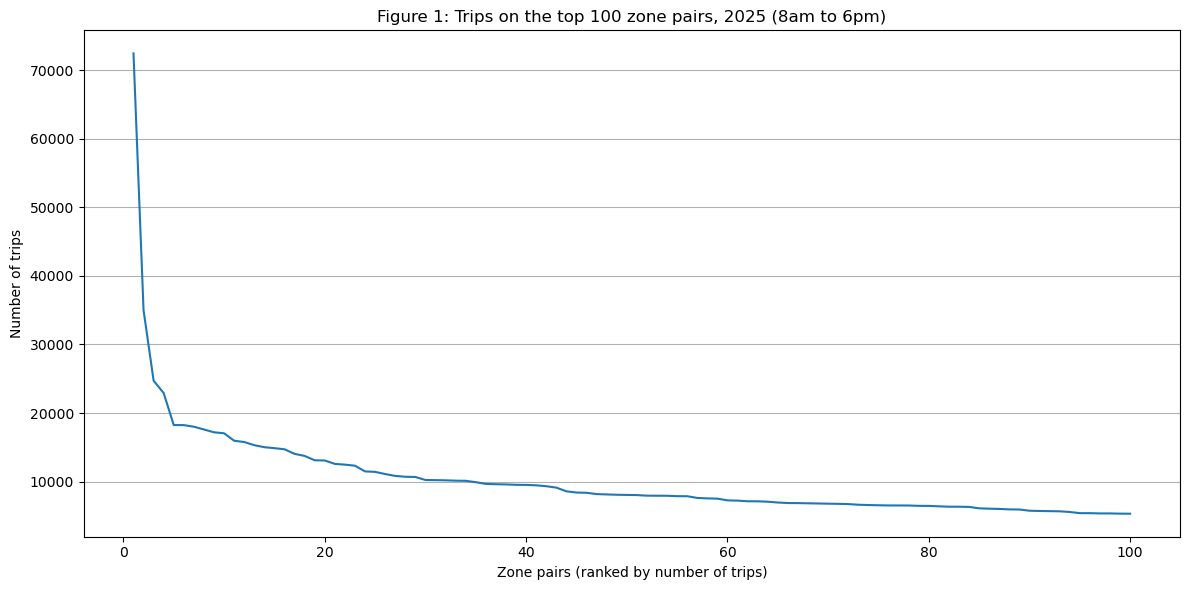

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 101), pdf["trips"])
plt.xlabel("Zone pairs (ranked by number of trips)")
plt.ylabel("Number of trips")
plt.title("Figure 1: Trips on the top 100 zone pairs, 2025 (8am to 6pm)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Visuals\trips_per_zone_pair.png",
            dpi=300, bbox_inches="tight")
plt.show()

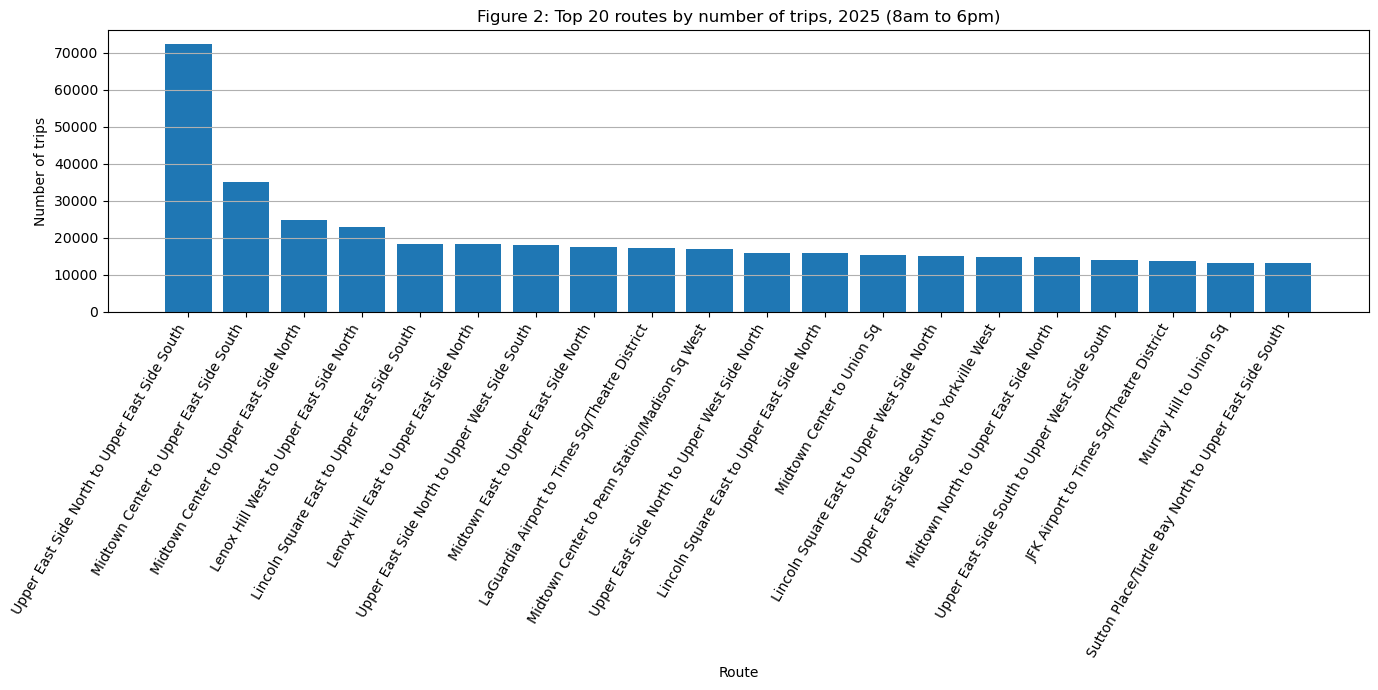

In [18]:
top20 = pair_counts.limit(20).toPandas()
top20["route"] = top20["zone_a_name"] + " to " + top20["zone_b_name"]

plt.figure(figsize=(14, 7))
plt.bar(top20["route"], top20["trips"], color="tab:blue")
plt.xticks(rotation=60, ha="right")
plt.xlabel("Route")
plt.ylabel("Number of trips")
plt.title("Figure 2: Top 20 routes by number of trips, 2025 (8am to 6pm)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Visuals\top_20_zone_pair.png",
            dpi=300, bbox_inches="tight")
plt.show()

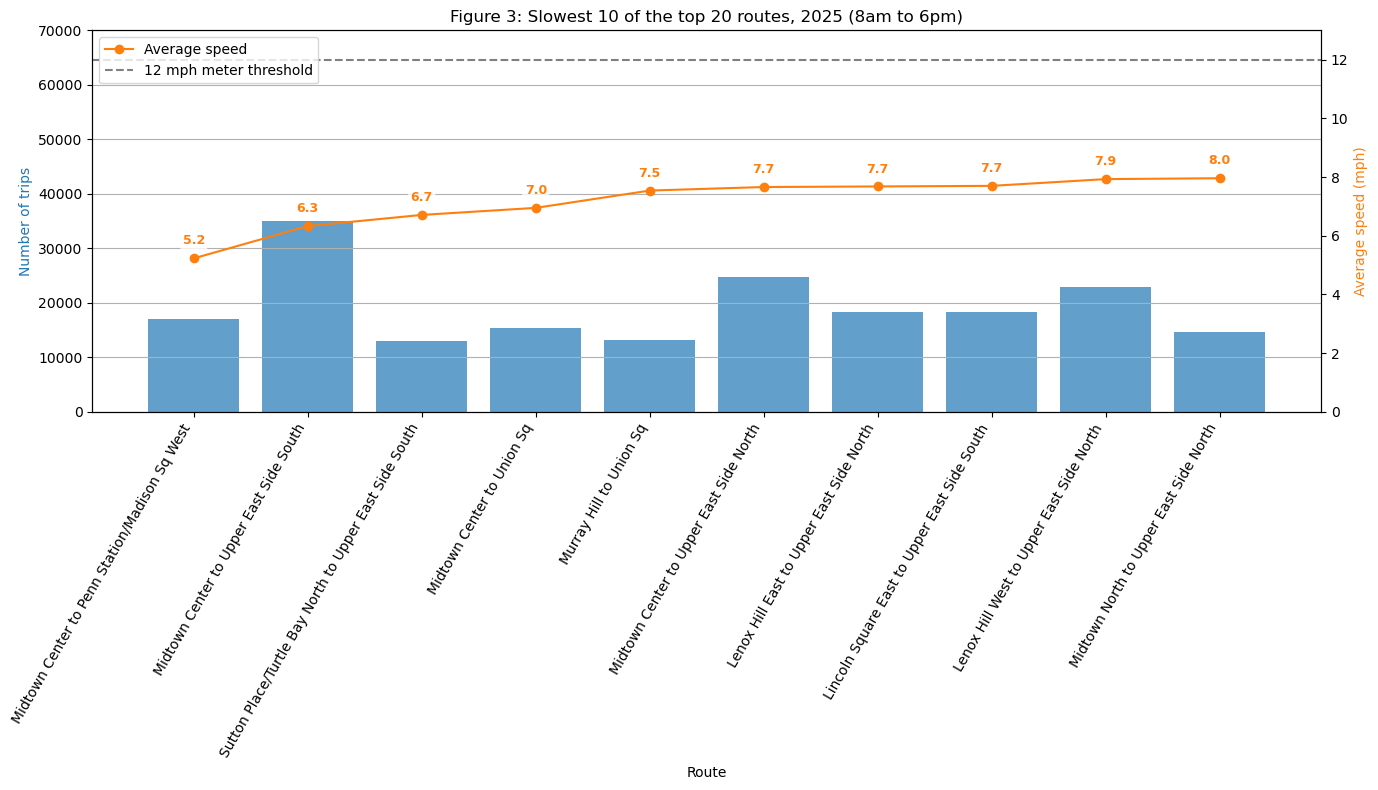

In [19]:
top20["route"] = top20["zone_a_name"] + " to " + top20["zone_b_name"]
slowest10 = top20.nsmallest(10, "avg_speed")


"Plotting the bar chart"
fig, ax1 = plt.subplots(figsize=(14, 8))
ax1.bar(slowest10["route"], slowest10["trips"], color="tab:blue", alpha=0.7)
ax1.set_xlabel("Route")
ax1.set_ylabel("Number of trips", color="tab:blue")
ax1.set_xticks(range(len(slowest10)))
ax1.set_xticklabels(slowest10["route"], rotation=60, ha="right")
ax1.grid(True, axis="y")
ax1.set_ylim(0, slowest10["trips"].max() * 2)     

"Plotting the line graph"
ax2 = ax1.twinx()
ax2.plot(slowest10["route"], slowest10["avg_speed"], color="tab:orange", marker="o", label="Average speed")
ax2.axhline(12, linestyle="--", color="grey", label="12 mph meter threshold")
ax2.set_ylabel("Average speed (mph)", color="tab:orange")
ax2.set_ylim(0, 13)                               
ax2.legend(loc="upper left")

"Looping over the average speeds and adding them as data callouts on the line graph"
for i, speed in enumerate(slowest10["avg_speed"]):
    ax2.annotate(f"{speed:.1f}", (i, speed), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9, color="tab:orange", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

plt.title("Figure 3: Slowest 10 of the top 20 routes, 2025 (8am to 6pm)")
plt.tight_layout()
plt.savefig(r"G:\My Drive\MIT Big Data Science\Semester 2\MIT805\group project\Visuals\final_zone_pairs.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [7]:
slowest10

,zone_a,zone_b,zone_a_name,zone_b_name,avg_speed,avg_distance,trips,route
9,161.0,186.0,Midtown Center,Penn Station/Madison Sq West,5.23,1.25,17045,Midtown Center to Penn Station/Madison Sq West
1,161.0,237.0,Midtown Center,Upper East Side South,6.33,1.02,35002,Midtown Center to Upper East Side South
19,229.0,237.0,Sutton Place/Turtle Bay North,Upper East Side South,6.71,1.02,13078,Sutton Place/Turtle Bay North to Upper East Si...
12,161.0,234.0,Midtown Center,Union Sq,6.95,1.40,15312,Midtown Center to Union Sq
18,170.0,234.0,Murray Hill,Union Sq,7.54,1.01,13107,Murray Hill to Union Sq
2,161.0,236.0,Midtown Center,Upper East Side North,7.66,1.85,24718,Midtown Center to Upper East Side North
5,140.0,236.0,Lenox Hill East,Upper East Side North,7.68,1.31,18237,Lenox Hill East to Upper East Side North
4,142.0,237.0,Lincoln Square East,Upper East Side South,7.70,1.28,18247,Lincoln Square East to Upper East Side South
3,141.0,236.0,Lenox Hill West,Upper East Side North,7.93,1.07,22907,Lenox Hill West to Upper East Side North
15,163.0,236.0,Midtown North,Upper East Side North,7.96,1.67,14713,Midtown North to Upper East Side North


### DAG

In [14]:
pair_counts.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   *(10) Sort [trips#327L DESC NULLS LAST], true, 0
   +- AQEShuffleRead coalesced
      +- ShuffleQueryStage 4
         +- Exchange rangepartitioning(trips#327L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=423]
            +- *(9) Project [zone_a#323, zone_b#324, Zone#295 AS zone_a_name#328, Zone#332 AS zone_b_name#329, avg_speed#325, avg_distance#326, trips#327L]
               +- *(9) BroadcastHashJoin [knownfloatingpointnormalized(normalizenanandzero(zone_b#324))], [knownfloatingpointnormalized(normalizenanandzero(cast(LocationID#330 as double)))], Inner, BuildRight, false
                  :- *(9) Project [zone_a#323, zone_b#324, avg_speed#325, avg_distance#326, trips#327L, Zone#295]
                  :  +- *(9) BroadcastHashJoin [knownfloatingpointnormalized(normalizenanandzero(zone_a#323))], [knownfloatingpointnormalized(normalizenanandzero(cast(LocationID#293 as double)))], Inner, BuildRight, fal